In [21]:
import numpy as np
import pandas as pd
from plotly.io import show
from matplotlib import pyplot as plt
import vectorbt as vbt
import mplfinance as mpf
import seaborn as sns
from tabulate import tabulate

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Backtest import Backtest
from ggTrader.Signals import Signals


Learning from part 1 and will revert to default for parameters that appear to have no correlation or little importance.

defaults:
- sar_maximum -->  0.2
- sar_acceleration --> 0.02
- ce_high_length --> 22
- atr_length --> 14


Explore further but can shrink search space:
- adx_length --> < 20
- adx_threshold -->  <25
- ce_low_length --> <20
- atr_multiplier --> <3

In [22]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
symbols = ["BTC"]
interval = "4h"
n_trials = 1000
sampler = RandomSampler(seed=42)  # optional seed for reproducibility
# sampler = TPESampler(seed=42)

# Time Range
end = pd.to_datetime("2025-06-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Indicator Params
params = {'sar_acceleration': 0.02,
          'sar_maximum': 0.2,
          'atr_multiplier': 3,
          'adx_threshold': 25,
          'adx_length': 14,
          'ce_high_length': 22,
          'ce_low_length': 22,
          'atr_length': 14,  # atr multiplier for chandelier exit
          }

# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
# df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)
df_multi = k.get_ohlcv_df(symbols, interval=interval)

# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]




#Optuna setup

In [23]:
import math


def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 20, 50)  #
    # params['adx_length'] = trial.suggest_int("adx_length", 2, 50)
    # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.01, 1, step=0.01)
    # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.05, 1, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 8, step=0.1)
    # params['atr_length'] = trial.suggest_int("atr_length", 2, 50)
    params['ce_low_length'] = trial.suggest_int("ce_low_length", 2, 100)
    # params['ce_high_length'] = trial.suggest_int("ce_high_length", 2, 200, step=2)
    s = Signals(**params)

    signals = s.calc_signals(df.copy())
    close = signals['close']
    entries = signals['entry_signal']
    exits = signals['exit_signal']
    # Build target allocation:
    # 1.0 = 100% of portfolio in asset
    # 0.0 = 100% in cash
    size = pd.Series(np.nan, index=close.index)
    size[entries] = 1.0   # on buy signal: go all-in
    size[exits] = 0.0     # on sell signal: go flat

    pf = vbt.Portfolio.from_orders(
        close=close,
        size=size,
        size_type='targetpercent',  # interpret `size` as target weight
        direction='longonly',
        init_cash=start_equity,           # starting cash
        fees=transaction_fee,                 # 0.1% fee (optional)
        slippage=0.0005,            # optional
    )
    stats = pf.stats()
    sharpe = stats['Sharpe Ratio']
    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    return sharpe


study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=n_trials)

[I 2025-11-07 22:06:18,024] A new study created in memory with name: no-name-0eb3e7f9-3a55-42d3-8b37-b19bb6e463be
[I 2025-11-07 22:06:18,269] Trial 0 finished with value: 1.704943636123304 and parameters: {'adx_threshold': 31, 'atr_multiplier': 7.7, 'ce_low_length': 74}. Best is trial 0 with value: 1.704943636123304.
[I 2025-11-07 22:06:18,494] Trial 1 finished with value: 0.338760406149775 and parameters: {'adx_threshold': 38, 'atr_multiplier': 2.1, 'ce_low_length': 17}. Best is trial 0 with value: 1.704943636123304.
[I 2025-11-07 22:06:18,715] Trial 2 finished with value: 1.3892522307127588 and parameters: {'adx_threshold': 21, 'atr_multiplier': 7.1000000000000005, 'ce_low_length': 61}. Best is trial 0 with value: 1.704943636123304.
[I 2025-11-07 22:06:18,958] Trial 3 finished with value: 1.5208798606968517 and parameters: {'adx_threshold': 41, 'atr_multiplier': 1.1, 'ce_low_length': 98}. Best is trial 0 with value: 1.704943636123304.
[I 2025-11-07 22:06:19,216] Trial 4 finished with

Study Results

In [24]:
trials = study.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))


|   number |      value |   adx_threshold |   atr_multiplier |   ce_low_length |
|----------|------------|-----------------|------------------|-----------------|
|      480 |  2.10554   |              50 |              1.6 |              68 |
|      239 |  2.08707   |              49 |              1.8 |              74 |
|      875 |  2.08432   |              49 |              1.6 |              70 |
|      887 |  1.98536   |              47 |              2.5 |              69 |
|      115 |  1.9387    |              39 |              5.5 |               6 |
|      759 |  1.918     |              35 |              5.5 |               9 |
|      448 |  1.91378   |              43 |              4   |              36 |
|      993 |  1.89998   |              50 |              4.1 |              25 |
|      403 |  1.89824   |              50 |              4   |              46 |
|      392 |  1.89637   |              44 |              1.7 |              77 |
|      821 |  1.89419   |   

In [25]:
best_params = study.best_params
best_value = study.best_value
print(f"\nBest --> Sortino: {best_value:.2f} ")
print(tabulate(best_params.items(), tablefmt="github"))


Best --> Sortino: 2.11 
|----------------|------|
| adx_threshold  | 50   |
| atr_multiplier |  1.6 |
| ce_low_length  | 68   |


Visualization

In [26]:
fig = optuna.visualization.plot_param_importances(study)
show(fig)

fig2 = optuna.visualization.plot_slice(study, params=best_params.keys())
show(fig2)


From the slice plot can notice a few things...

- ATR multiplier <2 also looks ideal as under 2 sortino values reach > 6
- ADX_length is good when < 10, I think best to cheap default of 14
- ADX_threshold looks like once it's under 20, there's not much correlation.
- ATR_length has little correlation so will keep at default of 14
- ce_high_length, keep the default value of 22
- ce_low_length the highest sortino values are achieved when ce_low_length is low, under 10
- sar_maximum is okay, keep the default of 0.2
- sar_acceleration is okay, keep the default of 0.02


Generally there aren't major correlations, but can generally see where there might be better results.  The slice plot does slightly agree with the most hyperparameter importance, since these are the only values that so some sort of correlation to sortino ratio.


NOTE:  Removed atr_length and ce_high_length from the slice plot, since they have very little correlation to sortino ratio.


In [27]:
fig3 = optuna.visualization.plot_optimization_history(study)
show(fig3)

Seaborn plots

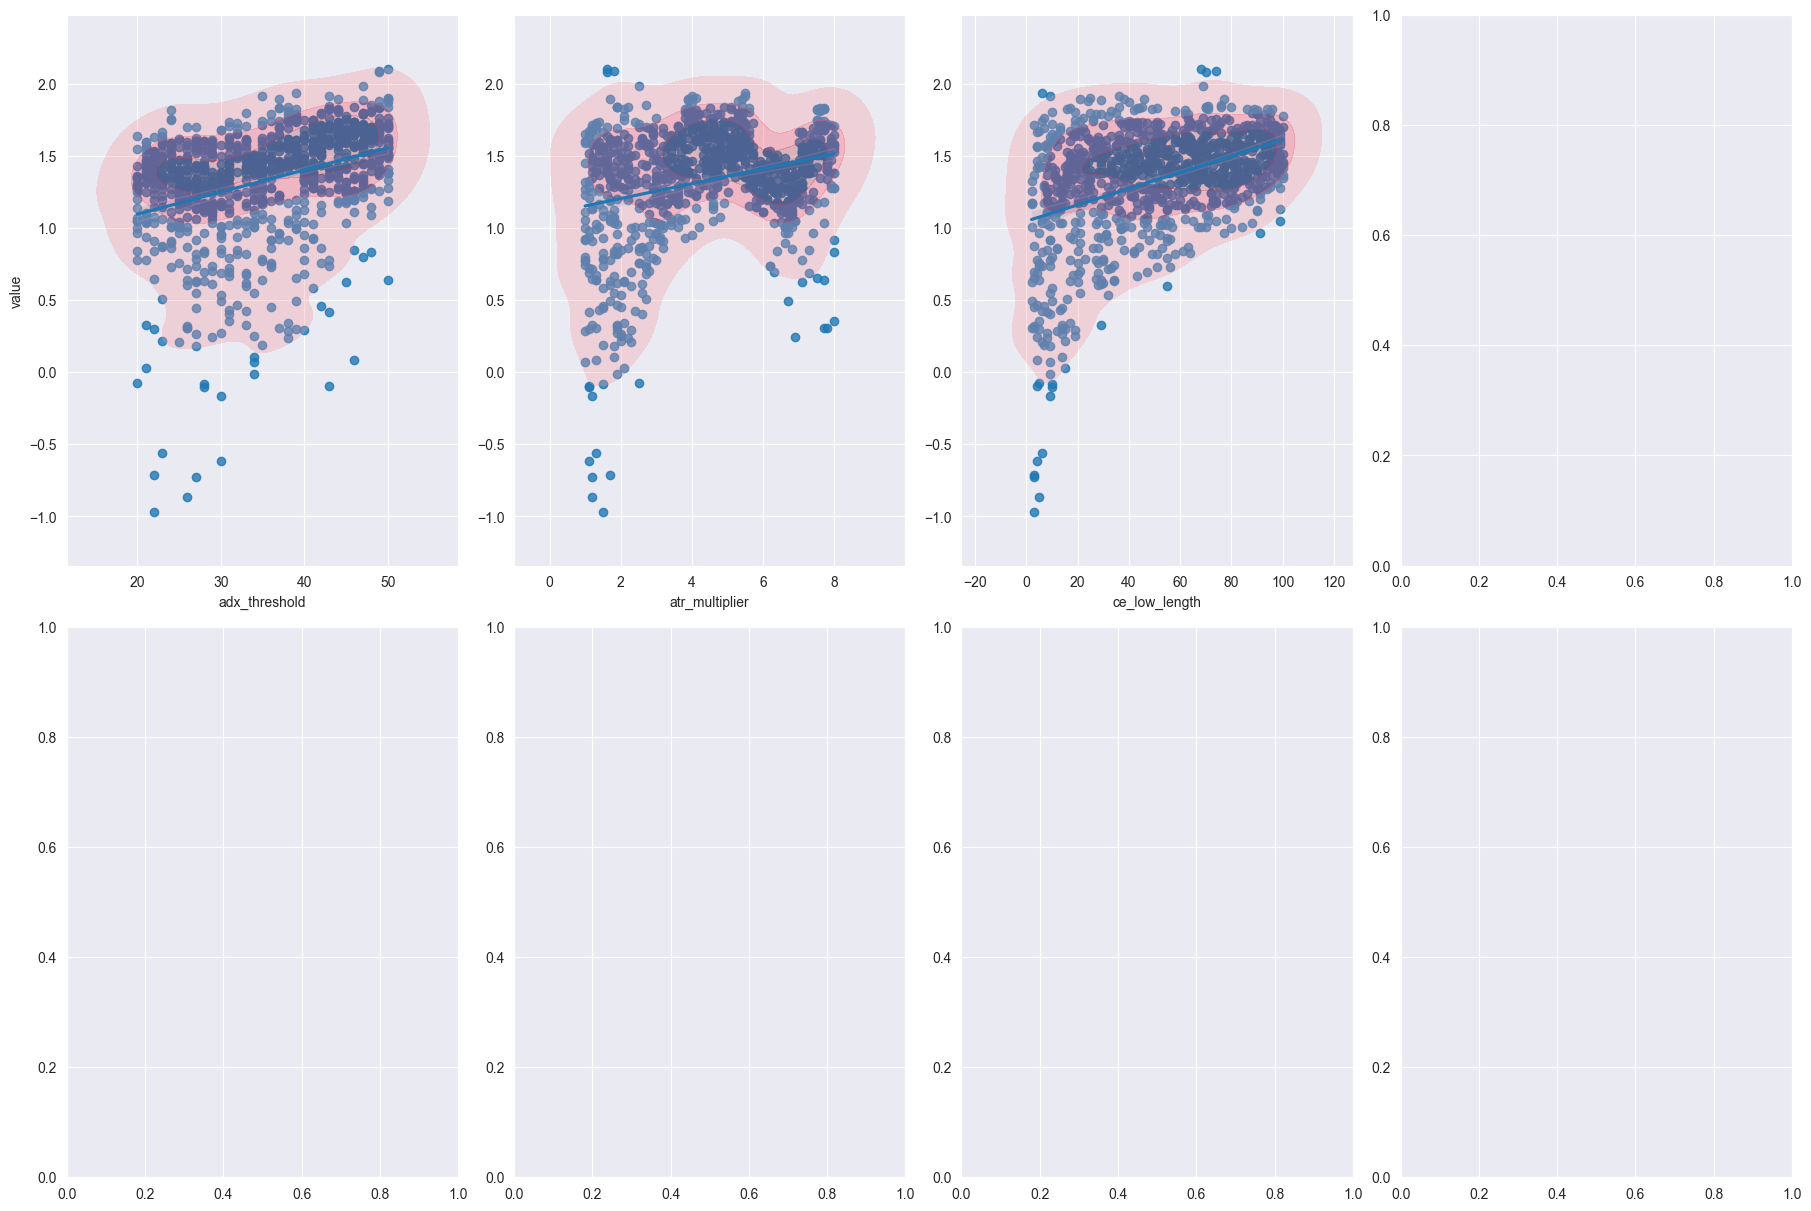

In [28]:
x_all = list(trials.columns[2:])
y_col = trials.columns[1]

fig, axes = plt.subplots(2, 4, figsize=(18, 12), constrained_layout=True)
for i, col in enumerate(x_all[:8]):  # first 8 columns
    ax = axes[i // 4, i % 4]
    sns.regplot(data=trials, x=col, y=y_col, ax=ax)
    sns.kdeplot(data=trials, x=col, y=y_col, levels=4, fill=True, color='crimson', alpha=0.3, ax=ax)
    ax.set_xlabel(col)
    if i % 4 != 0:
        ax.set_ylabel("")
plt.show()

Best Trial Backtest

In [29]:
for param in best_params.keys():
    params[param] = best_params[param]

s = Signals(**params)

signals = s.calc_signals(df.copy())
close = signals['close']
entries = signals['entry_signal']
exits = signals['exit_signal']
# Build target allocation:
# 1.0 = 100% of portfolio in asset
# 0.0 = 100% in cash
size = pd.Series(np.nan, index=close.index)
size[entries] = 1.0   # on buy signal: go all-in
size[exits] = 0.0     # on sell signal: go flat

pf = vbt.Portfolio.from_orders(
    close=close,
    size=size,
    size_type='targetpercent',  # interpret `size` as target weight
    direction='longonly',
    init_cash=start_equity,           # starting cash
    fees=transaction_fee,                 # 0.1% fee (optional)
    slippage=0.0005,            # optional
)
stats = pf.stats()
print(stats)

Start                         2023-01-01 00:00:00+00:00
End                           2025-06-30 00:00:00+00:00
Period                                911 days 04:00:00
Start Value                                      1000.0
End Value                                   3423.557216
Total Return [%]                             242.355722
Benchmark Return [%]                         556.866217
Max Gross Exposure [%]                            100.0
Total Fees Paid                                87.59918
Max Drawdown [%]                              14.627995
Max Drawdown Duration                 264 days 00:00:00
Total Trades                                          7
Total Closed Trades                                   7
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                  71.428571
Best Trade [%]                                42.582459
Worst Trade [%]                               -8

In [30]:
pf.plot(width=1600, height=1500).show()